In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [2]:
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']


N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_24852\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_24852\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[ 5 10  9 16 19  4 26 23  7 15 12 21 22 17  6 14 25 11  2  0 24  1]
>>> best_lam returning: 11.937766417144381
Singular values of W: [0.71199686 0.37634096 0.19149007]
Potent move norm^2: 3561.862838114612
Null move norm^2:   2345.5755852745046
Gamma (null/pot): 0.6585249606400003


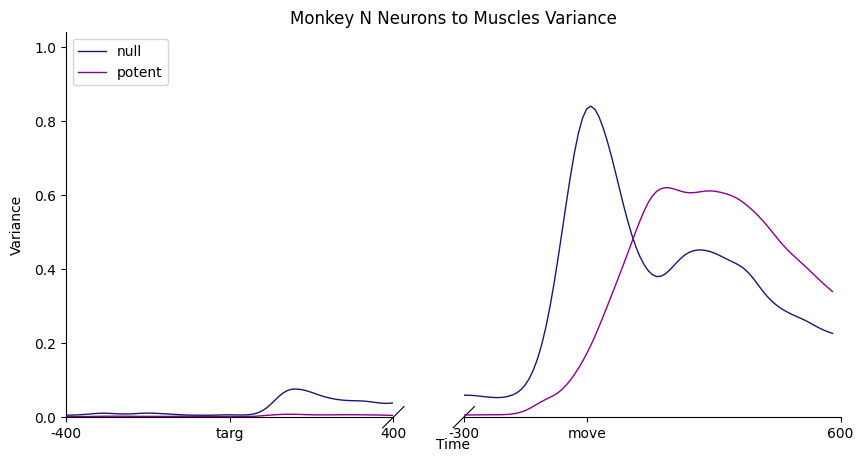

In [3]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[25 13 24 15 20 26 19  7  5 11  6  8  9  3  4 16 10 18 14  2 21 12]
>>> best_lam returning: 20.30917620904739
Singular values of W: [0.79639896 0.58252673 0.44422725]
Potent move norm^2: 2359.343921732685
Null move norm^2:   1649.1503246847728
Gamma (null/pot): 0.6989868282847246


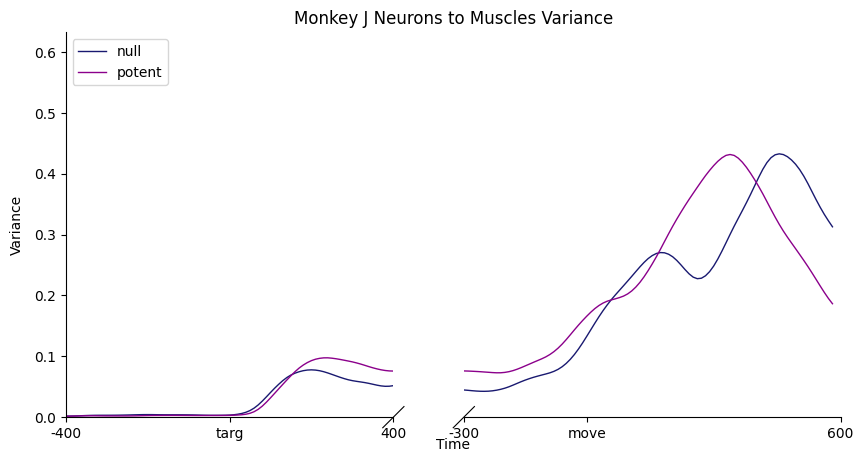

In [4]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[19  8 20  3  7  0 12 16 23 11 13  6 17 10  4 24 22 14 25  2 26  1]
>>> best_lam returning: 4.124626382901356
Singular values of W: [2.57028181 1.42929461 1.24093331 1.17547191 0.92756074 0.7772805
 0.66737184]
Potent move norm^2: 2665.9957693936835
Null move norm^2:   1946.7644182108013
Gamma (null/pot): 0.7302203703997422


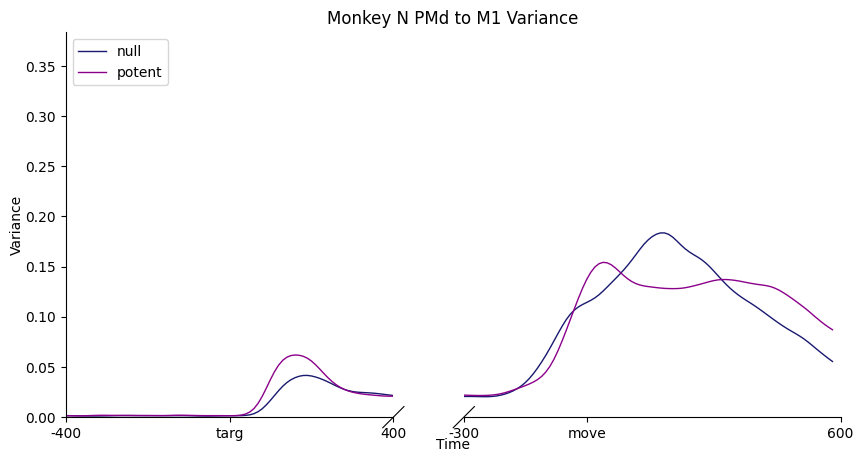

In [5]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[  9  67  94  48  86   4  36  92  52  28  73  39  81 106  84  78  75  22
  53  17  89 101  20  88  87 103   6  34 100   8  47  83  58  46   7  98
 102  61  95  57  55   2  44  37   3  16  96  80  90  15  50  51  32  59
  29  62  12  23  14  63  31  91  25  54  27  71   5  26  97 104  56  10
  93  82  30  35  33  49  69  21   1  42  77 107  64  24  18]
>>> best_lam returning: 20.30917620904739
Singular values of W: [1.48095827 1.16302145 0.9382038  0.8172911  0.65054548 0.58042995
 0.33620783]
Potent move norm^2: 6043.928013203833
Null move norm^2:   4006.5468189780527
Gamma (null/pot): 0.6629044572048464


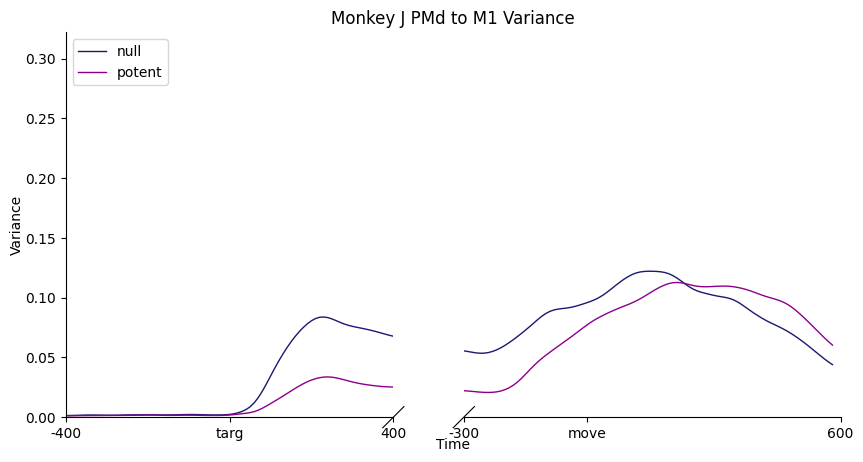

In [6]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 13  10  89  87  49  71  28   5  41  62  18 102  35  95   9  84  19  59
  55  26  50  23  51  34  33  48  79  30  76 106  25  99  70  73  77  54
  27   7  16  96  53  47  58  38  31  61  86  12  98  67  94  20  40  74
  11  72 103  66  29   2  78  65  93  75  63  22  39  45  69  64  17   1
  85  97  24  82  83 105  91  15   4  88  56  81   0  14  21]
>>> best_lam returning: 11.937766417144381
Singular values of W: [1.52858992 1.21609454 0.97063982 0.91219695 0.6966826  0.56297648
 0.36360459]
Potent move norm^2: 5809.672071446862
Null move norm^2:   4240.802760735023
Gamma (null/pot): 0.7299556168716556


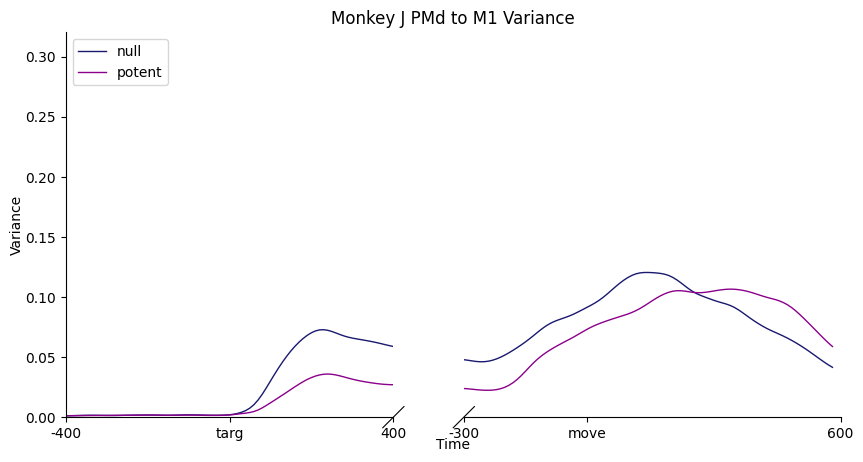

In [7]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[18  2 10  0 15  3 21 22 23  9  7  4  6 11 17 24 16 26 12  5  1 14]
>>> best_lam returning: 11.937766417144381
Singular values of W: [0.71248736 0.39080309 0.1956373 ]
Potent move norm^2: 3568.9256417256784
Null move norm^2:   2338.5127816634385
Gamma (null/pot): 0.655242786322861


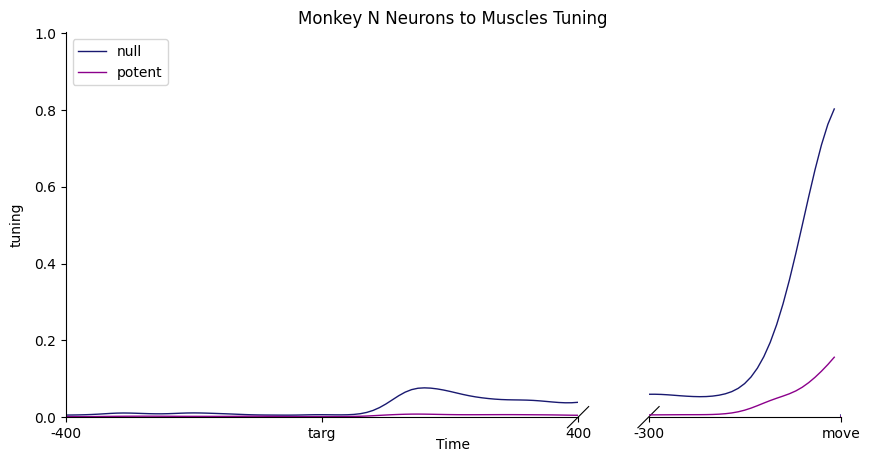

In [8]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)